In [67]:
# import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from sklearn.model_selection import train_test_split

In [29]:
# loading data
data = pd.read_csv(r"C:\Users\Prem\Desktop\ML projects\mnist.csv")
data

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41995,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
41996,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
41997,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
41998,6,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [30]:
# creating copy of data
df=data

In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42000 entries, 0 to 41999
Columns: 785 entries, label to pixel783
dtypes: int64(785)
memory usage: 251.5 MB


In [32]:
df[['label']]

,label
0,1
1,0
2,1
3,4
4,0
...,...
41995,0
41996,1
41997,7
41998,6


In [33]:
df['label'].unique()

array([1, 0, 4, 7, 3, 5, 8, 9, 2, 6])

In [34]:
# checking nulls
df.isnull().sum().sum()

np.int64(0)

In [35]:
# checking duplicates
df.duplicated().sum()

np.int64(0)

In [36]:
df.shape

(42000, 785)

### After cleaning data follow these steps

In [37]:
# splitting 
x=df.drop('label',axis=1)
y=df['label']

In [38]:
# normalization
x=x/225.0

In [39]:
print(x.shape)
print(y.shape)

(42000, 784)
(42000,)


In [44]:
# converting to arrays
x=np.array(x)
y=np.array(y)

In [45]:
# reshaping
x=x.reshape(-1,28,28,1)
y=y.reshape(-1)

In [46]:
print(x.shape)
print(y.shape)

(42000, 28, 28, 1)
(42000,)


In [48]:
#  train test split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [51]:
# model building
model = keras.Sequential([
    keras.layers.Input(shape=(28,28,1)),
    keras.layers.Conv2D(32,(3,3),activation='relu'), #32-neurons/filters (-8,16,32,64,128,256),(3,3) → Size of each filter
    keras.layers.MaxPooling2D((2,2)),               #(2,2)-
    keras.layers.Conv2D(64,(3,3),activation='relu'),
    keras.layers.MaxPooling2D((2,2)),
    keras.layers.Flatten(),
    keras.layers.Dense(128,activation='relu'),
    keras.layers.Dense(10,activation='softmax')
])

In [57]:
# compiling
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'])

In [63]:
# model training
hist = model.fit(x_train,y_train,epochs=9,validation_data=(x_test,y_test))

Epoch 1/9
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 20s 19ms/step - accuracy: 0.9994 - loss: 0.0022 - val_accuracy: 0.9893 - val_loss: 0.0471
Epoch 2/9
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 17s 17ms/step - accuracy: 0.9979 - loss: 0.0060 - val_accuracy: 0.9908 - val_loss: 0.0484
Epoch 3/9
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.9985 - loss: 0.0043 - val_accuracy: 0.9902 - val_loss: 0.0491
Epoch 4/9
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - accuracy: 0.9982 - loss: 0.0055 - val_accuracy: 0.9894 - val_loss: 0.0515
Epoch 5/9
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - accuracy: 0.9992 - loss: 0.0026 - val_accuracy: 0.9882 - val_loss: 0.0640
Epoch 6/9
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - accuracy: 0.9987 - loss: 0.0037 - val_accuracy: 0.9906 - val_loss: 0.0442
Epoch 7/9
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - accuracy: 0.9983 - loss: 0.0056 - val_accuracy: 0.9877 - val_loss: 0.0515
Epoch 8/9
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - accuracy: 0.9992 - loss: 0

In [64]:
# evaluation
model.evaluate(x_test,y_test)

263/263 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9918 - loss: 0.0389


[0.03889690712094307, 0.9917857050895691]

In [65]:
# prediction
predictions=model.predict(x_test)

263/263 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step 


C:\Users\Prem\AppData\Local\Temp\ipykernel_19560\3434438333.py:7: UserWarning: Legend does not support handles for str instances.
A proxy artist may be used instead.
See: https://matplotlib.org/stable/users/explain/axes/legend_guide.html#controlling-the-legend-entries
  plt.legend(['accuracy'],['val_accuracy'])


<function matplotlib.pyplot.show(close=None, block=None)>

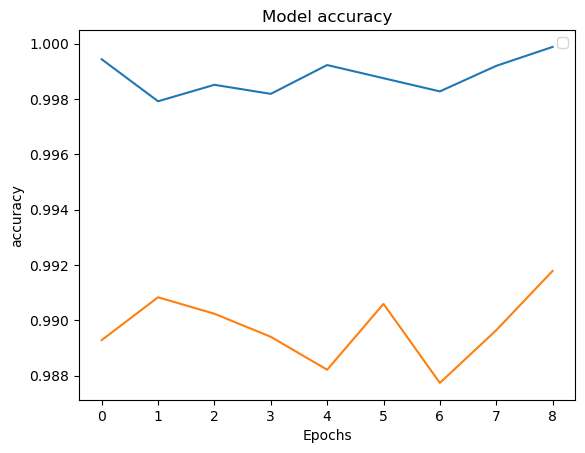

In [68]:
# visualize
plt.plot(hist.history['accuracy'])
plt.plot(hist.history['val_accuracy'])
plt.title('Model accuracy')
plt.xlabel('Epochs')
plt.ylabel('accuracy')
plt.legend(['accuracy'],['val_accuracy'])
plt.show